In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
bc_data = load_breast_cancer()

#X = pd.DataFrame(iris.data, columns=iris.feature_names)
X = pd.DataFrame( bc_data.data , columns=bc_data.feature_names)

# create temp_df to hold a 1-d array of 
y = bc_data.target


In [ ]:
# View the features and target variable
print(X.head())
print(y)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=20260310, stratify=y)

#instantiate the model
knn = KNeighborsClassifier(n_neighbors=6)
#fit the model to the training dataset
knn.fit(X_train, y_train)
# this code performance scores the model against the test data and prints the result as “accuracy”
print(knn.score(X_test, y_test))

# predict the target values as y_pred
y_pred = knn.predict(X_test)

# Predict the probabilities for the test set
y_probs = knn.predict_proba(X_test)[:, 1]

# print the confusion matrix comparing actual target against predicted target
print(confusion_matrix(y_test, y_pred) ) 

# print the classification report comparing actual target against predicted target
print(classification_report(y_test, y_pred) ) # prints 

print (np.sum(y_test))
print (len(y_test))




0.9090909090909091
[[46  7]
 [ 6 84]]
              precision    recall  f1-score   support

           0       0.88      0.87      0.88        53
           1       0.92      0.93      0.93        90

    accuracy                           0.91       143
   macro avg       0.90      0.90      0.90       143
weighted avg       0.91      0.91      0.91       143

90
143


In [14]:
# Calculate the AUC - ROC score
roc_auc = roc_auc_score(y_test, y_probs)

# Print the metrics
print(f"AUC - ROC Score: {roc_auc:.2f}")

AUC - ROC Score: 0.97


Number of threshold points: 8
Unique scores in predictions: 2


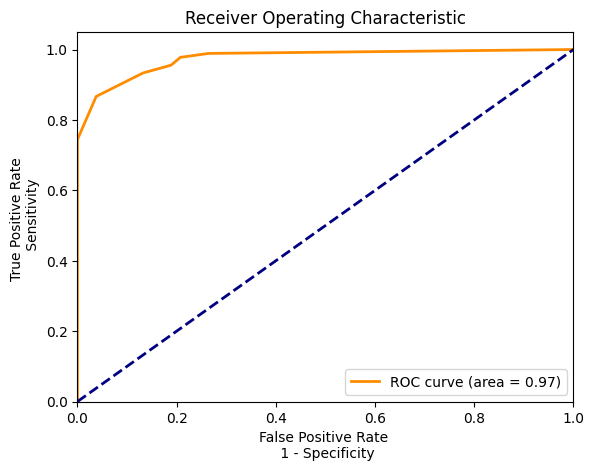

In [15]:
# Plotting the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

print(f"Number of threshold points: {len(thresholds)}")
print(f"Unique scores in predictions: {len(np.unique(y_pred))}")

roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate \n 1 - Specificity')
plt.ylabel('True Positive Rate \n Sensitivity')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
import sklearn
from sklearn import 
